In [2]:
import os
import datetime
# from netCDF4 import Dataset
import numpy as np
import pandas as pd
import xarray as xr
from scipy import signal, integrate, stats
import configparser

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib
from matplotlib.colors import BoundaryNorm, LogNorm
from matplotlib.ticker import MultipleLocator, FormatStrFormatter, AutoMinorLocator
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.mplot3d import Axes3D, axes3d

import cmaps, plt_helper, filter, lidar_processor

plt.style.use('latex_default.mplstyle')

In [3]:
"""EULAG simulations"""
# folder = "/work/bd0620/b309199/patagonia"
folder = "/scratch/b/b309199"

simulations = ["ideal_topo_L20_amp3000"]

slices = {"x": 0, "y": 0, "z": [0]}
xzs = []
yzs = []
for sim in simulations:
    fpath = os.path.join(folder, sim)
    ds, dsxz, dsyz, ds_xyslices = plt_helper.preprocess_eulag_output(fpath, slices=slices, load_ds=False)
    xzs.append(dsxz)
    yzs.append(dsyz)

In [4]:
dsxz

<xarray.Dataset> Size: 11GB
Dimensions:  (t: 1001, z: 321, x: 768, y: 768)
Coordinates:
    zcr      (t, z, x) float32 987MB 0.0 0.0 0.0 0.0 ... 128.0 128.0 128.0 128.0
    xcr      (y, x) float32 2MB -306.8 -306.0 -305.2 ... 305.2 306.0 306.8
    ycr      (y, x) float32 2MB -306.8 -306.8 -306.8 ... 306.8 306.8 306.8
    time     (t) float64 8kB 0.0 0.00625 0.0125 0.01875 ... 6.237 6.244 6.25
Dimensions without coordinates: t, z, x, y
Data variables:
    u        (t, z, x) float32 987MB ...
    v        (t, z, x) float32 987MB ...
    w        (t, z, x) float32 987MB ...
    th       (t, z, x) float32 987MB ...
    ue       (t, z, x) float32 987MB ...
    ve       (t, z, x) float32 987MB ...
    the      (t, z, x) float32 987MB ...
    ppe      (t, z, x) float32 987MB ...
    p        (t, z, x) float32 987MB ...
    rh0      (t, z, x) float32 987MB ...
Attributes: (12/51)
    j:        384
    ypos:     0.0
    nt:       15000
    nx:       768
    ny:       768
    nz:       321
    ...       ...
    rg:       287.04
    u0z:      0.0
    v0z:      0.0
    pref00:   100000.0
    cp:       1004.6400000000001
    cap:      0.2857142857142857

In [5]:
def emulate_airplane_measurement(ds, speed=220, xrange=None, dim='xcr'):
    """
    Emulate an airplane flying along one slice (x-axis) with dimensions (time, z, x).
    
    Parameters:
    - ds: xarray.Dataset with dimensions (time, z, x)
    - speed: speed of the airplane in m/s
    - range: Boundaries for airplane to turn around
    
    Returns:
    - xarray.DataArray with dimensions (time, z), representing the vertical
      profile at the airplane's position at each timestep.
    """

    ## Format dataset
    # ds = ds.set_coords('time')
    if dim == 'ycr':
        ds['y'] = ds['ycr'][:,0]
        ds = ds.set_coords('y')
        ds = ds.set_index({'y':'y'})
    else:
        ds['x'] = ds['xcr'][0,:]
        ds = ds.set_coords('x')
        ds = ds.set_index({'x':'x'})
    ds = ds.reset_coords('zcr', drop=False)

    ## Get x-locations of airplane for each timestep
    if xrange is None:
        xrange  = [ds[dim].min().values, ds[dim].max().values]
    xrange = [x * 1000 for x in xrange] # meter
    
    T = (xrange[1] - xrange[0]) / speed  # time for one leg
    tau = np.mod(ds.time.values * 3600, 2 * T)
    xlocs = np.where(tau < T, # tau < T -> forward flying
                    xrange[0] + speed * tau,
                    xrange[1] - speed * (tau - T))
    
    # Extract vertical profiles for each x-location
    if dim == 'ycr':
        vertical_profiles = [
            ds.isel(t=tstep).sel(y=xloc/1000, method='nearest')
            for tstep, xloc in enumerate(xlocs)
        ]
    else:
        vertical_profiles = [
            ds.isel(t=tstep).sel(x=xloc/1000, method='nearest')
            for tstep, xloc in enumerate(xlocs)
        ]
    result = xr.concat(vertical_profiles, dim='time')
    return result, xlocs

speed = 200
xrange=[-200,200]
dslid, xlocs = emulate_airplane_measurement(dsxz, speed=speed, xrange=xrange)
dslid

<xarray.Dataset> Size: 17MB
Dimensions:  (time: 1001, z: 321, y: 768)
Coordinates:
    xcr      (time, y) float32 3MB -199.6 -199.6 -199.6 ... 100.4 100.4 100.4
    ycr      (y) float32 3kB -306.8 -306.0 -305.2 -304.4 ... 305.2 306.0 306.8
  * time     (time) float64 8kB 0.0 0.00625 0.0125 0.01875 ... 6.237 6.244 6.25
    x        (time) float32 4kB -199.6 -195.6 -190.8 ... 109.2 104.4 100.4
Dimensions without coordinates: z, y
Data variables:
    u        (time, z) float32 1MB 0.0 0.0 0.0 0.0 ... -32.42 -31.72 -31.55
    v        (time, z) float32 1MB -0.0 -0.0 -0.0 ... -0.1841 0.02142 -0.4136
    w        (time, z) float32 1MB 0.0 0.0 0.0 0.0 ... -1.579 -1.116 -0.5597 0.0
    th       (time, z) float32 1MB 0.0 0.0 0.0 0.0 ... -101.4 -38.82 -1.972
    zcr      (time, z) float32 1MB 0.0 0.4 0.8 1.2 ... 126.8 127.2 127.6 128.0
    ue       (time, z) float32 1MB 0.0 0.0 0.0 0.0 ... -15.01 -14.96 -14.94
    ve       (time, z) float32 1MB -0.0 -0.0 -0.0 -0.0 -0.0 ... 0.0 0.0 0.0 0.0
    the      (time, z) float32 1MB 279.4 280.0 280.6 ... 1.039e+05 1.057e+05
    ppe      (time, z) float32 1MB 9.819e+04 9.348e+04 ... 0.0007427 0.0007166
    p        (time, z) float32 1MB -8.846e-12 -1.623e-11 ... -3.106e-05
    rh0      (time, z) float32 1MB 1.234 1.189 1.145 ... 5.248e-09 5.032e-09
Attributes: (12/51)
    j:        384
    ypos:     0.0
    nt:       15000
    nx:       768
    ny:       768
    nz:       321
    ...       ...
    rg:       287.04
    u0z:      0.0
    v0z:      0.0
    pref00:   100000.0
    cp:       1004.6400000000001
    cap:      0.2857142857142857

In [26]:
"""Subtracted legs from each other"""
"""Config"""
VERTICAL_CUTOFF = 15 # km (LAMBDA_CUT)
TEMPORAL_CUTOFF = 8*60 # min (TAU_CUT)

"""Colormap"""
mycmap = {}
mynorm = {}
myclev = {}
myclevl = {}
mylabel = {}

xvar = "vorticity"
# mycmap[xvar] = plt.get_cmap('RdBu')
mycmap[xvar] = plt.get_cmap('PiYG')
# clev_vort, clev_l_vort = plt_helper.get_colormap_bins_and_labels(max_level=0.2)
myclev[xvar] = np.linspace(-90,90,100) * 10**(-3)
myclevl[xvar] = [np.min(myclev[xvar]), np.max(myclev[xvar])]
mynorm[xvar] = BoundaryNorm(boundaries=myclev[xvar], ncolors=mycmap[xvar].N, clip=True)
mylabel[xvar] = "Vorticity / s$^{-1}$"

xvar = "t"
# mycmap[xvar] = plt.get_cmap('seismic')
mycmap[xvar] = cmaps.get_wave_cmap()
# clev_t, clev_l_t = plt_helper.get_colormap_bins_and_labels(max_level=32)
# myclev[xvar] = np.linspace(-25,25,100)
# myclev[xvar] = np.linspace(-30,30,100)
# myclev[xvar] = np.linspace(-20,20,100)
myclev[xvar] = np.linspace(-5,5,100)
myclevl[xvar] = [np.min(myclev[xvar]), np.max(myclev[xvar])]
mynorm[xvar] = BoundaryNorm(boundaries=myclev[xvar], ncolors=mycmap[xvar].N, clip=True)
mylabel[xvar] = r"T' / K"

surf_factor = 5

global xpp, ypp
xpp = 0.95
ypp = 0.98

def plot_vlidar(axlid, dslid, var="t", tstamp=0):

    time_res = (dslid.time[-1] - dslid.time[-2]).values * 60 # min
    tloc, tenv = plt_helper.get_eulag_t_and_tenv(dslid['th'].values, dslid['the'].values, dslid['p'].values, dslid['ppe'].values, ds.cap, ds.pref00)
    vert_res = (dslid.zcr[-1,-1] - dslid.zcr[-1,-2]).values
    tprime_bwf15, tbg15 = filter.butterworth_filter(tloc, cutoff=1/30, fs=1/vert_res, order=5, mode='both')
    tprime_bwf_time, _ = filter.butterworth_filter(tprime_bwf15.T, cutoff=1/(0.5*60), fs=1/time_res, order=5, mode='both')
    _, tbg_time = filter.butterworth_filter(tprime_bwf_time, cutoff=1/(0.1*60), fs=1/time_res, order=5, mode='both')
    
    if var == "t-env":
        cvar = tloc - tenv # no bwf
    elif var == "subtract legs":
        T = (xrange[1] - xrange[0]) * 1000 / speed / 3600  # time for one leg in h
        floored = np.floor(dslid.time.values / T)
        change_points = np.diff(floored, prepend=floored[0] - 1)  # force first point as different
        indices = np.where(change_points > 0)[0]
        tp = tloc - tenv
        tpsub = tp
        irange = indices[1]-indices[0]
        for ii in range(1, len(indices)-1, 1):
            i = indices[ii]
            im = i - irange
            ip = i + irange
            tpsub[im:i] =  tp[im:i] - np.flip(tp[i:ip], axis=0)
            if ii == len(indices)-2:
                tpsub[i:ip] = 0 * tp[i:ip]
            # tpsub[i:ip] = tp[i:ip] - np.flip(tp[im:i], axis=0)
            # tpsub[im:i] = 0 * tp[im:i]
        cvar = tpsub
    elif var == "vbwf_30km":
        cvar = tprime_bwf15 # only vertical bwf
    elif var == "tbwf_30min":
        cvar = tprime_bwf_time.T
    else:
        cvar = tbg_time.T # vertical and temporal bwf

    
    cmap = mycmap['t']
    norm = mynorm['t']
    clev = myclev['t']
    contf = axlid.contourf(dslid.time.expand_dims({'z':dslid.z},axis=1), dslid.zcr, cvar, levels=clev,
                        cmap=cmap, norm=norm, extend='both')

    
    # isentropes = axlid.contour(dslid.time, dslid.zcr, dslid.the + dslid.th, levels=thlev, colors='k', lw=lw2)
    # ax.clabel(isentropes, thlev[1::], fontsize=8, fmt='%1.0f K', inline_spacing=1, inline=True, 
    #             manual=[(8,ds.zcr[10,0,x]), (8,ds.zcr[-15,0,x])]) # ha='left', thlev[1::3]

    axlid.plot(dslid.time, surf_factor*dslid.zcr[:,0], lw=2, color='black')
    
    # axlid.yaxis.set_major_locator(MultipleLocator(10))
    axlid.xaxis.set_minor_locator(AutoMinorLocator())
    axlid.yaxis.set_minor_locator(AutoMinorLocator())
    # axlid.tick_params(which='both', labelbottom=False,labeltop=True, labelleft=False, labelright=True, left=False, right=True)
    # axlid.xaxis.set_label_position('top')
    # axlid.yaxis.set_label_position('right')
    # axlid.set_xlabel('time / h')
    # axlid.set_ylabel('altitude z / km')
    # axlid.set_xlim(xlim_lid)
    # axlid.set_ylim(zlim)
    axlid.grid()

    hrs, rem = divmod(tstamp*3600, 3600)
    mins, secs = divmod(rem, 60)
    axlid.axvline(x=[tstamp], color='black', lw=1, ls='--') # ymin=zlim[0],ymax=zlim[1]
    t = 0
    # axlid.text(1-xpp, ypp-0.1, f"Time: {int(hrs):02d}:{int(mins):02d}:{int(secs):02d}s ({t:03d})", transform=axlid.transAxes, weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
    # if 'xpos' in dslid.attrs:
    #     axlid.text(1-xpp, ypp, f"x: {dslid.xpos:.1f}km, y: {dslid.ypos:.1f}km", transform=axlid.transAxes, weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
    
    return axlid, contf

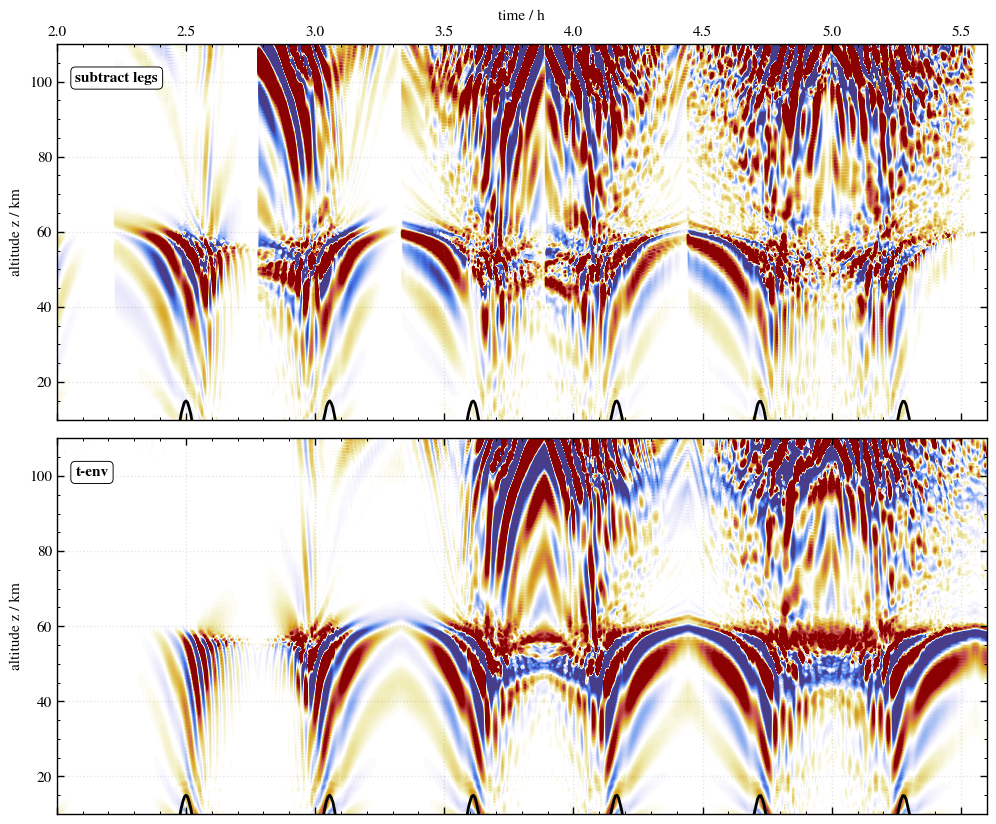

In [28]:
"""Figure stuff"""
gskw  = {'hspace':0.05, 'wspace':0.03, 'height_ratios': [1,1]} #  , 'width_ratios': [5,5]}
fig, axes = plt.subplots(2,1, figsize=(12,10), sharex=True, gridspec_kw=gskw)

plots = ["subtract legs", "t-env"]
for i, plot in enumerate(plots):
    ax = axes[i]
    ax, _ = plot_vlidar(ax, dslid, var=plot)
    ax.tick_params(labelbottom=False,labeltop=True, labelleft=True)
    ax.xaxis.set_label_position('top')
    # axes[0,0].yaxis.set_label_position('right')
    ax.set_xlim(2,5.6)
    ax.set_ylim(10,110)
    if i==0:
        ax.set_xlabel('time / h')
        ax.tick_params(which='both', labelbottom=False,labeltop=True, top=True, bottom=True, left=True, right=True)
    else:
        ax.tick_params(which='both', labelbottom=False, labeltop=False)
    ax.set_ylabel('altitude z / km')
    ax.text(0.02, 0.9, plot, transform=ax.transAxes, weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

fig_title = "sublegs_vlidar_alima.png"
imagefolder = "../data/figures"
fig.savefig(os.path.join(imagefolder,fig_title), facecolor='w', edgecolor='w',
            format='png', dpi=240, bbox_inches='tight')

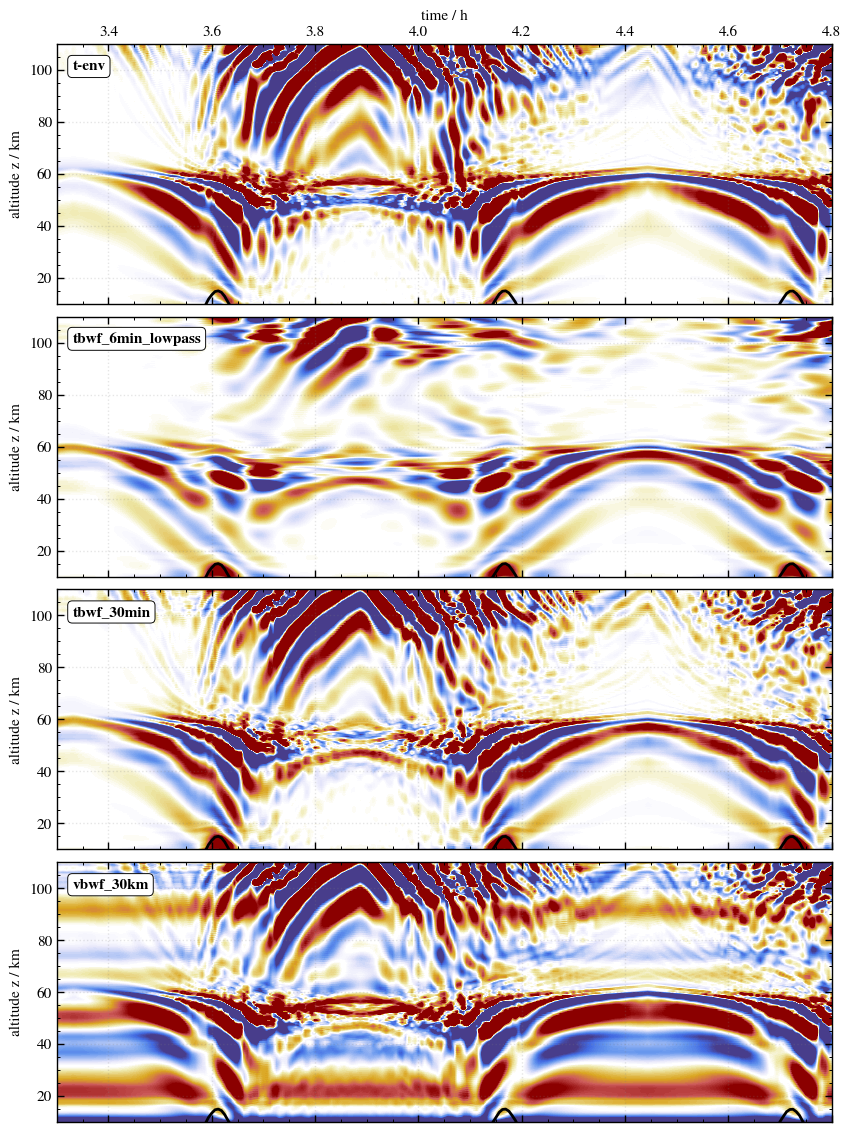

In [39]:
"""Figure stuff"""
gskw  = {'hspace':0.05, 'wspace':0.03, 'height_ratios': [1,1,1,1]} #  , 'width_ratios': [5,5]}
fig, axes = plt.subplots(4,1, figsize=(10,14), sharex=True, gridspec_kw=gskw)

plots = ["t-env", "tbwf_6min_lowpass", "tbwf_30min", "vbwf_30km"]
for i, plot in enumerate(plots):
    ax = axes[i]
    ax, _ = plot_vlidar(ax, dslid, var=plot)
    ax.tick_params(labelbottom=False,labeltop=True, labelleft=True)
    ax.xaxis.set_label_position('top')
    # axes[0,0].yaxis.set_label_position('right')
    ax.set_xlim(3.3,4.8)
    ax.set_ylim(10,110)
    if i==0:
        ax.set_xlabel('time / h')
        ax.tick_params(which='both', labelbottom=False,labeltop=True, top=True, bottom=True, left=True, right=True)
    else:
        ax.tick_params(which='both', labelbottom=False, labeltop=False)
    ax.set_ylabel('altitude z / km')
    ax.text(0.02, 0.9, plot, transform=ax.transAxes, weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

fig_title = "filter_vlidar_alima.png"
imagefolder = "../data/figures"
fig.savefig(os.path.join(imagefolder,fig_title), facecolor='w', edgecolor='w',
            format='png', dpi=240, bbox_inches='tight')